# RB1S (RBOB) — Feature Engineering for Metamodel

This notebook engineers RB1S-specific features (crack spreads, seasonality, rolling vols, interactions) and prepares a `rb1s_model_features.csv` for modeling.


In [1]:
# Install dependencies (uncomment to run if needed)
# %pip install pandas numpy matplotlib seaborn xgboost scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')

DATA_DIR = Path('MetaModel')
OHLCV_PATH = DATA_DIR / 'ohlcv_data.csv'
PRIMARY_SIGNALS_PATH = DATA_DIR / 'primary_signals.csv'
LABELED_PATH = DATA_DIR / 'labeled_signals.csv'

print('Data paths:')
print(OHLCV_PATH)
print(PRIMARY_SIGNALS_PATH)
print(LABELED_PATH)


Data paths:
MetaModel\ohlcv_data.csv
MetaModel\primary_signals.csv
MetaModel\labeled_signals.csv


In [3]:
# Load data (robust to missing files)
if not OHLCV_PATH.exists():
    raise FileNotFoundError(f"{OHLCV_PATH} not found. Please ensure data is in MetaModel/ folder")

ohlcv = pd.read_csv(OHLCV_PATH, parse_dates=['date'])
print('ohlcv shape', ohlcv.shape)

if PRIMARY_SIGNALS_PATH.exists():
    primary_signals = pd.read_csv(PRIMARY_SIGNALS_PATH, parse_dates=['date'])
    print('primary_signals shape', primary_signals.shape)
else:
    print('primary_signals.csv not found; continuing without it')
    primary_signals = None

if LABELED_PATH.exists():
    labeled = pd.read_csv(LABELED_PATH, parse_dates=['date'])
    print('labeled_signals shape', labeled.shape)
else:
    print('labeled_signals.csv not found; continuing without it')
    labeled = None

# Keep only instruments of interest and lowercase instrument names
ohlcv['instrument'] = ohlcv['instrument'].str.lower()
insts = ['rb1s','cl1s','ho1s']
ohlcv = ohlcv[ohlcv['instrument'].isin(insts)].copy()

# Pivot close prices to wide form
close_wide = ohlcv.pivot_table(index='date', columns='instrument', values='close')
close_wide = close_wide.sort_index()
print('close_wide columns:', close_wide.columns.tolist())


ohlcv shape (83547, 8)
primary_signals shape (645, 12)
labeled_signals shape (1176, 6)
close_wide columns: ['cl1s', 'ho1s', 'rb1s']


In [4]:
# Compute RB-specific features
features = pd.DataFrame(index=close_wide.index)

if 'cl1s' in close_wide.columns and 'rb1s' in close_wide.columns:
    features['crack_cl_rb'] = close_wide['cl1s'] - close_wide['rb1s']
    features['crack_cl_rb_ratio'] = close_wide['cl1s'] / close_wide['rb1s']
else:
    print('CL1S or RB1S not present — skipping crack features')

if 'ho1s' in close_wide.columns and 'rb1s' in close_wide.columns:
    features['rb_vs_ho'] = close_wide['rb1s'] - close_wide['ho1s']
    features['rb_vs_ho_ratio'] = close_wide['rb1s'] / close_wide['ho1s']

# Term structure / roll proxy: use 21-day forward - current if front-month futures present
# If futures columns like rb1s_1m exist, user may adjust; here we compute simple momentum proxies
features['rb_close'] = close_wide.get('rb1s')
features['rb_ret_1d'] = features['rb_close'].pct_change(1)
features['rb_ret_3d'] = features['rb_close'].pct_change(3)
features['rb_ret_5d'] = features['rb_close'].pct_change(5)

# Rolling volatility
features['rb_vol_10d'] = features['rb_ret_1d'].rolling(10).std()
features['rb_vol_20d'] = features['rb_ret_1d'].rolling(20).std()

# Volume / OI features from ohlcv if present
vol_wide = ohlcv.pivot_table(index='date', columns='instrument', values='volume')
if 'rb1s' in vol_wide.columns:
    features['rb_volume'] = vol_wide['rb1s']
    features['rb_volume_z_20'] = (features['rb_volume'] - features['rb_volume'].rolling(20).mean()) / features['rb_volume'].rolling(20).std()

# Seasonality
features['month'] = features.index.month
features['is_summer'] = features['month'].isin([4,5,6,7,8,9]).astype(int)
features['dayofweek'] = features.index.dayofweek

# EWMA/decay features
features['rb_ewm_ret_5'] = features['rb_ret_1d'].ewm(span=5).mean()

# Interaction example
if 'crack_cl_rb' in features.columns and 'rb_vol_10d' in features.columns:
    features['crack_x_vol'] = features['crack_cl_rb'] * features['rb_vol_10d']

features = features.reset_index().rename(columns={'index':'date'})
print('Engineered features shape:', features.shape)
features.head()


Engineered features shape: (8171, 18)


,date,crack_cl_rb,crack_cl_rb_ratio,rb_vs_ho,rb_vs_ho_ratio,rb_close,rb_ret_1d,rb_ret_3d,rb_ret_5d,rb_vol_10d,rb_vol_20d,rb_volume,rb_volume_z_20,month,is_summer,dayofweek,rb_ewm_ret_5,crack_x_vol
0,1990-01-02,22.2331,34.845486,-0.1170,0.848818,0.6569,NaN,NaN,NaN,NaN,NaN,13854.0,NaN,1,0,1,NaN,NaN
1,1990-01-03,23.0077,35.222371,-0.1097,0.859719,0.6723,0.023443,NaN,NaN,NaN,NaN,12399.0,NaN,1,0,2,0.023443,NaN
2,1990-01-04,22.7571,35.855414,-0.0790,0.892062,0.6529,-0.028856,NaN,NaN,NaN,NaN,12314.0,NaN,1,0,3,-0.007936,NaN
3,1990-01-05,22.4578,37.094182,-0.0561,0.917293,0.6222,-0.047021,-0.052824,NaN,NaN,NaN,10698.0,NaN,1,0,4,-0.026450,NaN
4,1990-01-08,21.0352,36.969904,-0.0585,0.909063,0.5848,-0.060109,-0.130150,NaN,NaN,NaN,8661.0,NaN,1,0,0,-0.040432,NaN


In [5]:
# Merge with primary signals and labeled (if present) to build model dataset for RB1S
# primary_signals is wide-format (date + instrument columns) — melt to long if present
if primary_signals is not None:
    primary_long = primary_signals.melt(id_vars='date', var_name='instrument', value_name='signal')
    primary_long['instrument'] = primary_long['instrument'].str.lower()
else:
    primary_long = None

if labeled is not None:
    labeled['instrument'] = labeled['instrument'].str.lower()

# Keep only RB1S rows
model_features = features.copy()
model_features['instrument'] = 'rb1s'

if primary_long is not None:
    model_features = model_features.merge(
        primary_long[primary_long['instrument']=='rb1s'][['date','signal']],
        on='date', how='left'
    )
else:
    model_features['signal'] = np.nan

if labeled is not None:
    model_features = model_features.merge(
        labeled[labeled['instrument']=='rb1s'][['date','label']],
        on='date', how='left'
    )
else:
    model_features['label'] = np.nan

print('model_features shape:', model_features.shape)
model_features.head()


model_features shape: (8171, 21)


,date,crack_cl_rb,crack_cl_rb_ratio,rb_vs_ho,rb_vs_ho_ratio,rb_close,rb_ret_1d,rb_ret_3d,rb_ret_5d,rb_vol_10d,...,rb_volume,rb_volume_z_20,month,is_summer,dayofweek,rb_ewm_ret_5,crack_x_vol,instrument,signal,label
0,1990-01-02,22.2331,34.845486,-0.1170,0.848818,0.6569,NaN,NaN,NaN,NaN,...,13854.0,NaN,1,0,1,NaN,NaN,rb1s,NaN,NaN
1,1990-01-03,23.0077,35.222371,-0.1097,0.859719,0.6723,0.023443,NaN,NaN,NaN,...,12399.0,NaN,1,0,2,0.023443,NaN,rb1s,NaN,NaN
2,1990-01-04,22.7571,35.855414,-0.0790,0.892062,0.6529,-0.028856,NaN,NaN,NaN,...,12314.0,NaN,1,0,3,-0.007936,NaN,rb1s,NaN,NaN
3,1990-01-05,22.4578,37.094182,-0.0561,0.917293,0.6222,-0.047021,-0.052824,NaN,NaN,...,10698.0,NaN,1,0,4,-0.026450,NaN,rb1s,NaN,NaN
4,1990-01-08,21.0352,36.969904,-0.0585,0.909063,0.5848,-0.060109,-0.130150,NaN,NaN,...,8661.0,NaN,1,0,0,-0.040432,NaN,rb1s,NaN,NaN


Saved MetaModel\rb1s_model_features.csv


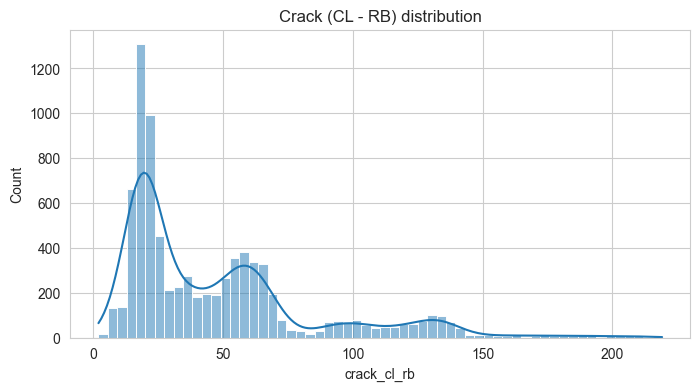

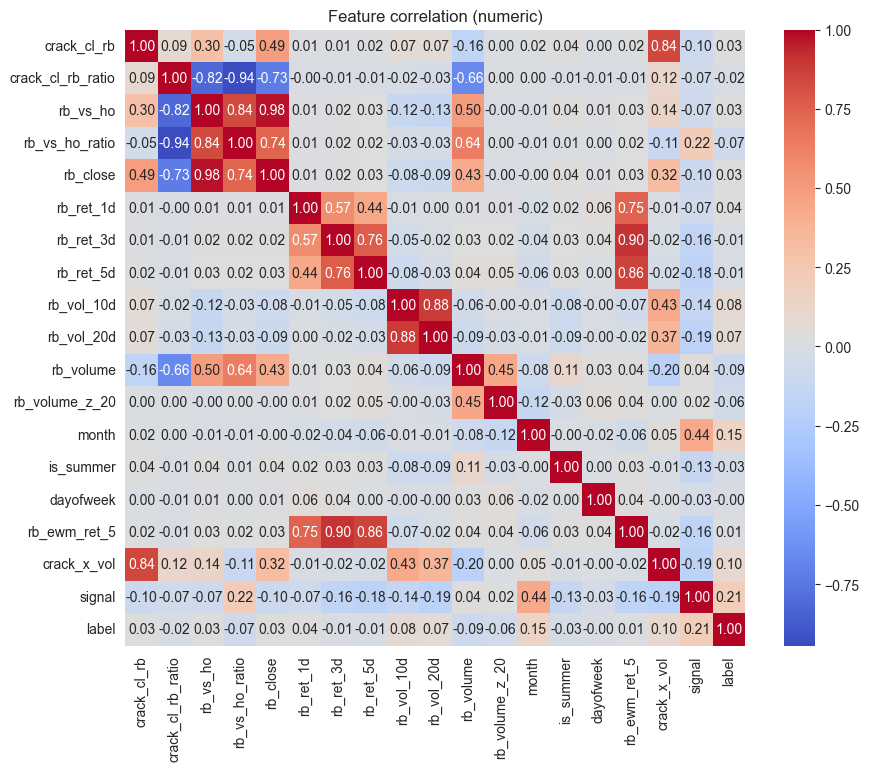

In [6]:
# Save model features for later modeling
OUT_PATH = DATA_DIR / 'rb1s_model_features.csv'
model_features.to_csv(OUT_PATH, index=False)
print('Saved', OUT_PATH)

# Quick exploratory plots
plt.figure(figsize=(8,4))
if 'crack_cl_rb' in model_features.columns:
    sns.histplot(model_features['crack_cl_rb'].dropna(), bins=60, kde=True)
    plt.title('Crack (CL - RB) distribution')
    plt.show()

# Correlation heatmap of numeric features
num_cols = model_features.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    corr = model_features[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Feature correlation (numeric)')
    plt.show()
